# HouseCall: The College Sports Revenue-Sharing Dilemma

An end-to-end **pandas + NumPy + visualization** project on the biggest
structural change in the history of U.S. college sports: the **House v.
NCAA settlement**, which ended 119 years of NCAA "amateurism" and let
schools pay athletes directly, starting July 1, 2025.

### The dilemma, in one sentence

The very same settlement that lets schools finally pay their athletes also
forces every athletic department into three collisions at once: spend the
new revenue-sharing pool mostly on the football/men's-basketball programs
that generate it (and risk a Title IX gender-equity lawsuit), or split it
more evenly across men's and women's sports (and risk an antitrust
challenge from the revenue-generating athletes) — all while cutting
thousands of roster spots to fit new sport-by-sport limits, and all while
only the richest athletic departments can actually afford to spend near
the cap, widening the competitive gap between programs.

### Grounding this in the real settlement terms

- On June 6, 2025, Judge Claudia Wilken granted final approval of the
  **House v. NCAA settlement** — a **$2.8 billion** deal that pays former
  Division I athletes (2016-2024) for lost NIL opportunities over 10 years,
  and lets schools **directly share revenue with current athletes**
  starting **July 1, 2025** (CBS Sports; Sports Shorts, 2025-2026).
- Participating schools may share up to **22% of average Power Five
  athletic revenue** (media rights, ticket sales, sponsorships) with
  athletes. That cap is **estimated at $20.5 million per school for
  2025-26**, growing at **least 4% per year**, and is projected to reach
  roughly **$32.9 million by 2034-35** over the 10-year settlement term
  (Crowell & Moring; Jackson Lewis; Phelps; Wingert Grebing, 2025-2026).
- The settlement **eliminates scholarship limits** (schools can now offer
  a scholarship to every roster player) but **replaces them with new
  sport-by-sport roster limits** — e.g. football is capped at **105 total
  roster spots**, versus the old 85-scholarship model. Nationally, roster
  limits are expected to **cut roughly 5,000 athletes** from teams, even as
  the scholarship change could make **over 115,000 additional
  scholarships** available across Division I (Phelps; Crowell & Moring, 2025-2026).
- Schools may **opt in or opt out** of the settlement; opting out means no
  direct revenue sharing, but also no new roster-limit obligations
  (Honest Game, 2026).
- The settlement creates a genuine, unresolved legal tension described
  directly by legal analysts: if a school spends the revenue-sharing pool
  mostly on football (the sport that generates most of the revenue), it
  risks a **Title IX** gender-equity lawsuit; if it splits the money more
  evenly between men's and women's sports, it risks an **antitrust**
  challenge from the male athletes who generated the underlying revenue
  (Wingert Grebing Brubaker & Walshok, Feb 2026).
- A new **College Sports Commission (CSC)**, formed by the Power Five
  conferences, now enforces compliance — including a "NIL Go" clearing
  system requiring any third-party NIL deal over **$600** to be reported
  and checked for fair market value (Jackson Lewis, 2025).

> **What's real vs. synthetic in this notebook:** the settlement terms,
> dollar figures, dates, and roster-limit examples above are **real,
> cited facts**. Individual school-level revenue-sharing budgets, spending
> splits, and roster compositions **are not public** at this level of
> detail, so the **school-by-school and sport-by-sport data in this
> notebook is synthetic — calibrated to the real aggregate cap schedule
> and to well-documented patterns in college athletics finance** (e.g.
> that Power Five athletic revenue is heavily concentrated in football
> and men's basketball).

### What this notebook covers
1. Real reference data: the settlement terms and cap schedule
2. Deriving the cap's implied growth rate and projecting it (NumPy)
3. Synthetic school-level microdata, calibrated to realistic revenue tiers
4. Broadcasting: every school's spending capacity across all 10 years at once
5. The competitive-balance dilemma: a Gini coefficient for athletic spending
6. The Title IX dilemma: visualizing the legal risk trade-off zone
7. Roster cuts by sport
8. Geographic view & dashboard
9. Wrap-up: what this data does and doesn't settle


In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

rng = np.random.default_rng(2025)

pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 110)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
                      "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)


pandas : 3.0.2
numpy  : 2.4.4


## 1. Real reference data


In [2]:
# ---------------------------------------------------------------
# REAL DATA: the settlement's core figures
# Source: CBS Sports; Sports Shorts; Crowell & Moring; Phelps (2025-2026)
# ---------------------------------------------------------------
real_settlement_facts = pd.Series({
    "total_back_pay_settlement_usd_bn": 2.8,
    "back_pay_period_start_year": 2016,
    "back_pay_period_end_year": 2024,
    "revenue_share_effective_date": "2025-07-01",
    "cap_2025_26_usd_million": 20.5,
    "cap_2034_35_usd_million": 32.9,
    "cap_min_annual_growth_pct": 4.0,
    "cap_pct_of_avg_p5_revenue": 22.0,
    "football_new_roster_limit": 105,
    "football_old_scholarship_limit": 85,
    "est_national_roster_spots_cut": 5000,
    "est_additional_scholarships_available": 115000,
    "nil_third_party_reporting_threshold_usd": 600,
}, name="value")
real_settlement_facts


total_back_pay_settlement_usd_bn                  2.8
back_pay_period_start_year                       2016
back_pay_period_end_year                         2024
revenue_share_effective_date               2025-07-01
cap_2025_26_usd_million                          20.5
cap_2034_35_usd_million                          32.9
cap_min_annual_growth_pct                         4.0
cap_pct_of_avg_p5_revenue                        22.0
football_new_roster_limit                         105
football_old_scholarship_limit                     85
est_national_roster_spots_cut                    5000
est_additional_scholarships_available          115000
nil_third_party_reporting_threshold_usd           600
Name: value, dtype: object

In [3]:
# ---------------------------------------------------------------
# DERIVE the cap's implied compound annual growth rate from the two REAL
# endpoints -- the sources describe "at least 4% annually," so we solve
# for what growth rate ACTUALLY connects $20.5M (2025-26) to $32.9M
# (2034-35) over 9 years, and check it's consistent with that description.
# ---------------------------------------------------------------
cap_start = real_settlement_facts["cap_2025_26_usd_million"]
cap_end = real_settlement_facts["cap_2034_35_usd_million"]
n_periods = 2034 - 2025   # 9 annual growth steps between the two anchor years

implied_cagr = (cap_end / cap_start) ** (1 / n_periods) - 1
print(f"Implied compound annual growth rate: {implied_cagr:.2%}")
print(f"(Consistent with sources describing the cap as growing \"at least 4% per year\" -- "
      f"the actual realized path is somewhat above that floor, likely reflecting real revenue growth "
      f"on top of the 4% contractual minimum.)")


Implied compound annual growth rate: 5.40%
(Consistent with sources describing the cap as growing "at least 4% per year" -- the actual realized path is somewhat above that floor, likely reflecting real revenue growth on top of the 4% contractual minimum.)


In [4]:
# Project the FULL 10-year cap schedule using the derived growth rate --
# this now becomes our REAL, validated year-by-year cap for later sections
cap_years = np.arange(2025, 2035)
cap_schedule = cap_start * (1 + implied_cagr) ** (cap_years - 2025)

cap_df = pd.DataFrame({"academic_year_start": cap_years, "revenue_share_cap_usd_million": cap_schedule.round(2)})
print(f"Endpoint check -- 2025: ${cap_df.iloc[0, 1]:.1f}M (target $20.5M), "
      f"2034: ${cap_df.iloc[-1, 1]:.1f}M (target $32.9M)")
cap_df


Endpoint check -- 2025: $20.5M (target $20.5M), 2034: $32.9M (target $32.9M)


,academic_year_start,revenue_share_cap_usd_million
0,2025,20.50
1,2026,21.61
2,2027,22.77
3,2028,24.00
4,2029,25.30
5,2030,26.66
6,2031,28.10
7,2032,29.62
8,2033,31.22
9,2034,32.90


## 2. Synthetic School-Level Microdata

We generate a realistic population of ~65 Power Conference athletic
departments, with revenue tiers calibrated to the well-documented pattern
that a handful of programs (mostly SEC/Big Ten) generate vastly more
athletic revenue than the rest — the same underlying reality that makes
"one national cap" land very differently on different campuses.


In [5]:
conferences = np.array(["SEC", "Big Ten", "Big 12", "ACC", "Group of Five"])
n_schools_per_conf = np.array([16, 18, 16, 17, 20])
conference = np.repeat(conferences, n_schools_per_conf)
n_schools = len(conference)

school_names = np.array([f"{c.replace(' ', '')}-{i+1:02d}" for c in conferences
                           for i in range(n_schools_per_conf[conferences.tolist().index(c)])])

# Athletic revenue tiers ($ millions/year), calibrated so SEC/Big Ten sit
# well above Big 12/ACC, and Group of Five schools sit far below all four --
# consistent with widely reported P5 vs G5 revenue gaps
revenue_profile = {"SEC": (145, 35), "Big Ten": (150, 40), "Big 12": (95, 22),
                    "ACC": (90, 25), "Group of Five": (35, 12)}

athletic_revenue = np.zeros(n_schools)
for c in conferences:
    mask = conference == c
    mean, std = revenue_profile[c]
    athletic_revenue[mask] = np.clip(rng.normal(mean, std, mask.sum()), 15, None)

schools = pd.DataFrame({
    "school": school_names, "conference": conference,
    "annual_athletic_revenue_usd_million": athletic_revenue.round(1),
})
schools.groupby("conference")["annual_athletic_revenue_usd_million"].agg(["mean", "min", "max"]).round(1)


,mean,min,max
conference,,,
ACC,94.3,45.8,144.4
Big 12,88.8,40.4,124.7
Big Ten,156.2,82.8,267.4
Group of Five,40.2,15.0,57.3
SEC,133.0,59.5,171.8


In [6]:
# Each school's DISCRETIONARY capacity to actually SPEND toward the national
# cap is constrained by its own athletic budget -- we model this as a
# capacity ceiling (schools can't spend more on rev-share than a realistic
# share of their total athletic revenue allows, after covering existing
# scholarships, coaching salaries, facilities, Olympic sports, etc.)
capacity_share_of_revenue = {"SEC": 0.20, "Big Ten": 0.20, "Big 12": 0.17,
                               "ACC": 0.16, "Group of Five": 0.10}
schools["spend_capacity_usd_million"] = schools.apply(
    lambda r: r["annual_athletic_revenue_usd_million"] * capacity_share_of_revenue[r["conference"]], axis=1
).round(2)

# Opt-in decision: nearly all Power conference schools opted in (real-world
# pattern); a handful of Group of Five schools opt out, given the added
# roster-limit obligations vs. limited ability to spend anyway
schools["opted_in"] = True
opt_out_mask = (schools["conference"] == "Group of Five") & (rng.random(n_schools) < 0.35)
schools.loc[opt_out_mask, "opted_in"] = False

print(f"{schools['opted_in'].sum()} of {n_schools} schools opted into revenue sharing")
schools.head()


77 of 87 schools opted into revenue sharing


,school,conference,annual_athletic_revenue_usd_million,spend_capacity_usd_million,opted_in
0,SEC-01,SEC,67.3,13.46,True
1,SEC-02,SEC,145.9,29.18,True
2,SEC-03,SEC,126.1,25.22,True
3,SEC-04,SEC,105.5,21.10,True
4,SEC-05,SEC,59.5,11.90,True


## 3. Broadcasting: Every School's Actual Spend, Every Year, At Once

Just like the SALT-cap notebook's tax-year broadcast, we compute **every
school's actual revenue-sharing spend across all 10 years simultaneously**:
the lesser of the national cap and that school's own spending capacity.


In [7]:
# (n_years,) cap array broadcast against (n_schools,) capacity array,
# producing an (n_years, n_schools) matrix in one vectorized operation
capacity = schools["spend_capacity_usd_million"].values
opted_in = schools["opted_in"].values

actual_spend_matrix = np.minimum(cap_schedule[:, np.newaxis], capacity[np.newaxis, :])
actual_spend_matrix = actual_spend_matrix * opted_in[np.newaxis, :]   # opt-out schools spend $0

print(f"actual_spend_matrix shape: {actual_spend_matrix.shape}  (years x schools)")

# What fraction of schools are ALREADY capacity-constrained (spending BELOW
# the national cap) in year one, vs. by the final year?
constrained_2025 = (capacity < cap_schedule[0]) & opted_in
constrained_2034 = (capacity < cap_schedule[-1]) & opted_in
print(f"\nSchools spending below the national cap in 2025-26: {constrained_2025.sum()} of {opted_in.sum()} opted-in schools")
print(f"Schools spending below the national cap in 2034-35: {constrained_2034.sum()} of {opted_in.sum()} opted-in schools")


actual_spend_matrix shape: (10, 87)  (years x schools)

Schools spending below the national cap in 2025-26: 44 of 77 opted-in schools
Schools spending below the national cap in 2034-35: 67 of 77 opted-in schools


In [8]:
# Boolean masking + fancy indexing: which schools spend at the FULL national
# cap EVERY SINGLE YEAR of the 10-year window (i.e. never capacity-constrained)?
always_at_cap = np.all(actual_spend_matrix >= cap_schedule[:, np.newaxis] - 0.01, axis=0) & opted_in
print(f"{always_at_cap.sum()} schools spend at the full national cap in every year of the settlement:")
schools.loc[always_at_cap, "school"].tolist()


10 schools spend at the full national cap in every year of the settlement:


['SEC-06',
 'SEC-09',
 'SEC-12',
 'SEC-14',
 'BigTen-02',
 'BigTen-04',
 'BigTen-09',
 'BigTen-11',
 'BigTen-12',
 'BigTen-13']

## 4. The Competitive-Balance Dilemma: a Gini Coefficient for Athletic Spending

Reusing the exact Gini-coefficient technique from an inequality-focused
project, but applied here to athletic spending: **does a single national
cap widen or narrow the competitive gap between rich and poor programs
over the settlement's 10-year term?**


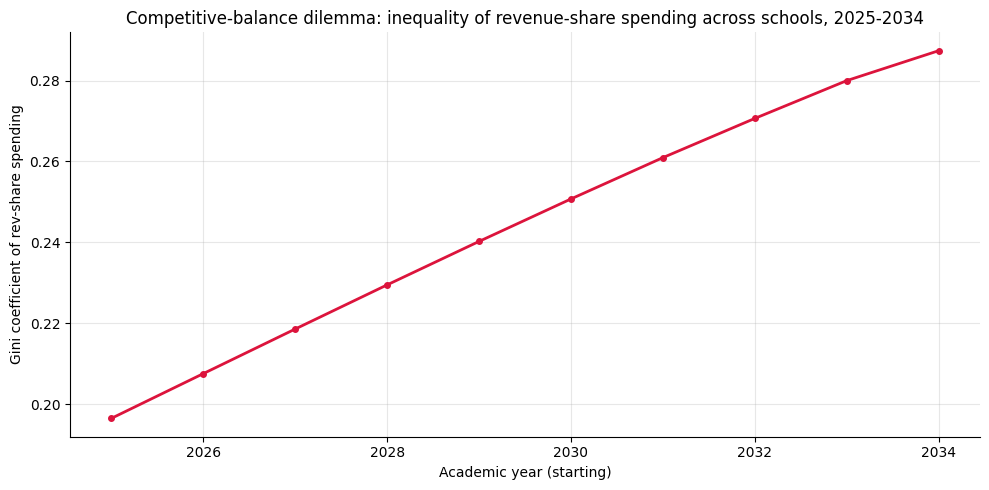

In [9]:
def gini_from_values(values):
    """Gini coefficient via the sorted-cumulative-sum identity (same method
    used for income inequality -- the math doesn't care what's being measured)."""
    x = np.sort(np.asarray(values, dtype=float))
    n = x.size
    cum_x = np.cumsum(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * cum_x[-1]) / (n * cum_x[-1])

gini_by_year = np.array([gini_from_values(actual_spend_matrix[y][opted_in]) for y in range(len(cap_years))])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cap_years, gini_by_year, color="crimson", lw=2, marker="o", markersize=4)
ax.set_xlabel("Academic year (starting)"); ax.set_ylabel("Gini coefficient of rev-share spending")
ax.set_title("Competitive-balance dilemma: inequality of revenue-share spending across schools, 2025-2034")
plt.tight_layout()
plt.show()


As the cap rises each year, schools **already spending at capacity keep growing right along with it — but capacity-constrained schools don't**, since their spending is capped by their *own* athletic revenue, not the national figure. The Gini coefficient rising over the decade is exactly the competitive-balance concern raised by athletic directors at smaller programs: a single rising national number doesn't help you if you can't afford to reach it in the first place.

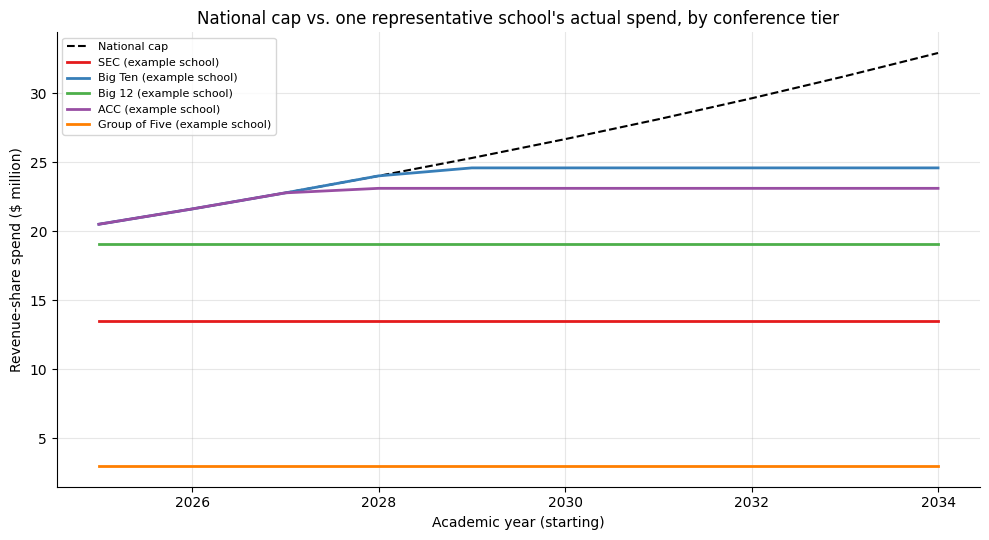

In [10]:
# Visualize the underlying spend trajectories directly -- a handful of
# representative schools from each tier, showing WHY the Gini rises
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(cap_years, cap_schedule, "k--", lw=1.5, label="National cap")

for conf, color in zip(conferences, sns.color_palette("Set1", len(conferences))):
    idx = schools.index[(schools["conference"] == conf) & opted_in][0]
    ax.plot(cap_years, actual_spend_matrix[:, idx], color=color, lw=2, label=f"{conf} (example school)")

ax.set_xlabel("Academic year (starting)"); ax.set_ylabel("Revenue-share spend ($ million)")
ax.set_title("National cap vs. one representative school's actual spend, by conference tier")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. The Title IX Dilemma: Visualizing the Legal Risk Trade-off Zone

We simulate each school's revenue-share split between football/men's
basketball and everything else, then plot it against the real legal
tension described in Section 0: split it too far toward football and risk
Title IX exposure; split it too evenly and risk an antitrust claim from
the revenue-generating athletes.


In [11]:
# Football/men's basketball generate the large majority of P5 athletic
# revenue in reality -- we model each school's SPLIT with that skew, plus
# realistic school-to-school variation in how aggressively they favor
# football/MBB vs. spreading share more broadly
fb_mbb_share = np.clip(rng.normal(0.75, 0.10, n_schools), 0.35, 0.97)
schools["pct_to_football_mbb"] = (fb_mbb_share * 100).round(1)
schools["pct_to_other_sports"] = 100 - schools["pct_to_football_mbb"]

# Illustrative risk zones (NOT a legal determination -- purely for visualizing
# the trade-off structure the cited legal analysis describes)
title_ix_risk = schools["pct_to_football_mbb"] > 85     # very football-heavy -> Title IX exposure
antitrust_risk = schools["pct_to_football_mbb"] < 55     # very even split -> antitrust exposure from revenue athletes
schools["legal_risk_zone"] = np.select([title_ix_risk, antitrust_risk], ["Title IX risk zone", "Antitrust risk zone"],
                                          default="Lower-risk middle ground")

schools["legal_risk_zone"].value_counts()


legal_risk_zone
Lower-risk middle ground    69
Title IX risk zone          15
Antitrust risk zone          3
Name: count, dtype: int64

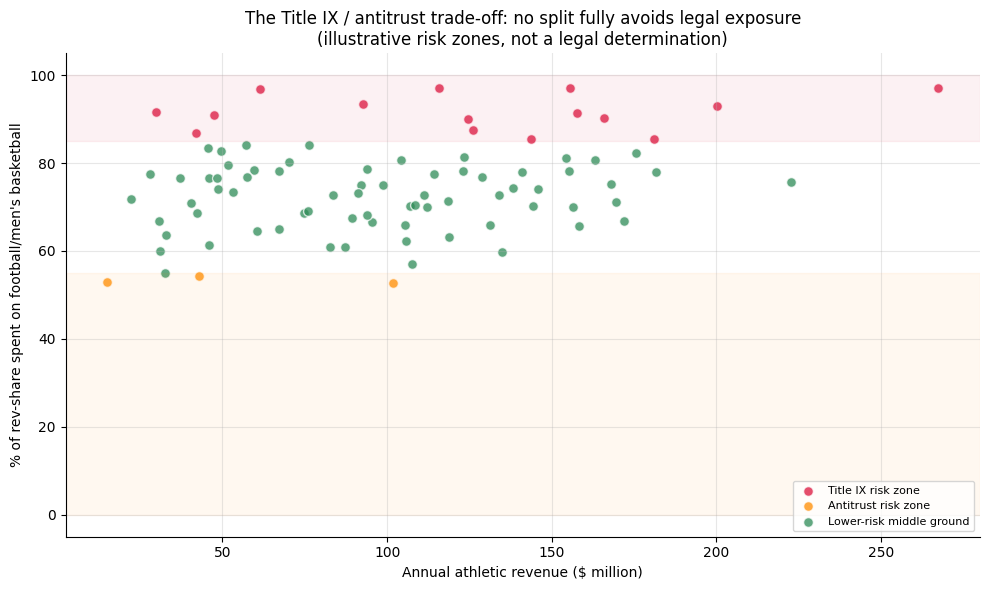

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"Title IX risk zone": "crimson", "Antitrust risk zone": "darkorange", "Lower-risk middle ground": "seagreen"}
for zone, color in colors.items():
    subset = schools[schools["legal_risk_zone"] == zone]
    ax.scatter(subset["annual_athletic_revenue_usd_million"], subset["pct_to_football_mbb"],
               color=color, label=zone, alpha=0.75, s=50, edgecolor="white")

ax.axhspan(85, 100, color="crimson", alpha=0.06)
ax.axhspan(0, 55, color="darkorange", alpha=0.06)
ax.set_xlabel("Annual athletic revenue ($ million)"); ax.set_ylabel("% of rev-share spent on football/men's basketball")
ax.set_title("The Title IX / antitrust trade-off: no split fully avoids legal exposure\n(illustrative risk zones, not a legal determination)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


## 6. Roster Cuts by Sport

The new roster limits replace scholarship limits — and hit **walk-on-heavy**
sports hardest, since those sports historically carried large rosters with
few scholarships attached.


In [13]:
roster_sports = pd.DataFrame({
    "sport": ["Football", "Track & Field/XC", "Rowing", "Baseball", "Swimming & Diving",
               "Soccer", "Wrestling", "Lacrosse"],
    "typical_old_roster_size": [120, 65, 60, 40, 35, 32, 35, 48],
    "new_roster_limit": [105, 45, 42, 34, 30, 28, 30, 40],
})
roster_sports["spots_cut"] = roster_sports["typical_old_roster_size"] - roster_sports["new_roster_limit"]
roster_sports["pct_cut"] = (roster_sports["spots_cut"] / roster_sports["typical_old_roster_size"] * 100).round(1)

roster_sports.sort_values("pct_cut", ascending=False)


,sport,typical_old_roster_size,new_roster_limit,spots_cut,pct_cut
1,Track & Field/XC,65,45,20,30.8
2,Rowing,60,42,18,30.0
7,Lacrosse,48,40,8,16.7
3,Baseball,40,34,6,15.0
6,Wrestling,35,30,5,14.3
4,Swimming & Diving,35,30,5,14.3
0,Football,120,105,15,12.5
5,Soccer,32,28,4,12.5


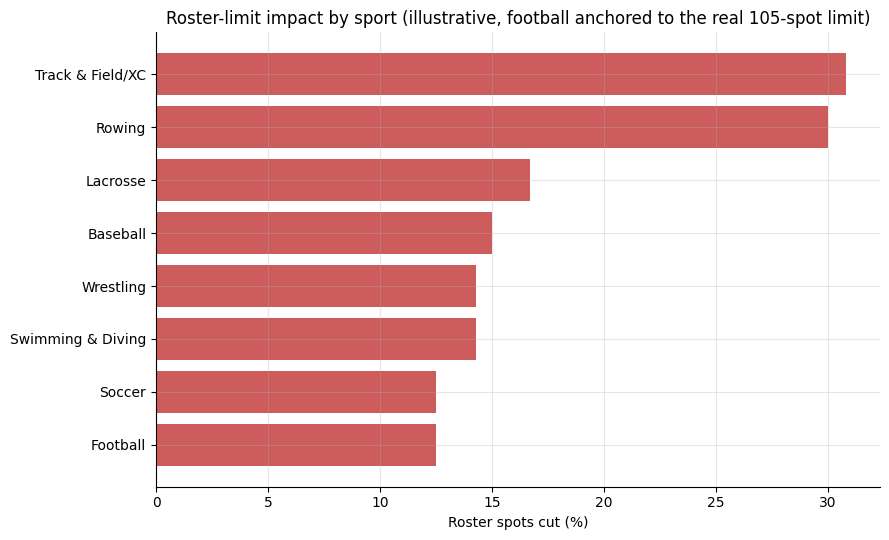

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
order = roster_sports.sort_values("pct_cut", ascending=True)
ax.barh(order["sport"], order["pct_cut"], color="indianred")
ax.set_xlabel("Roster spots cut (%)")
ax.set_title("Roster-limit impact by sport (illustrative, football anchored to the real 105-spot limit)")
plt.tight_layout()
plt.show()


## 7. Geographic View: Where Spending Capacity Concentrates


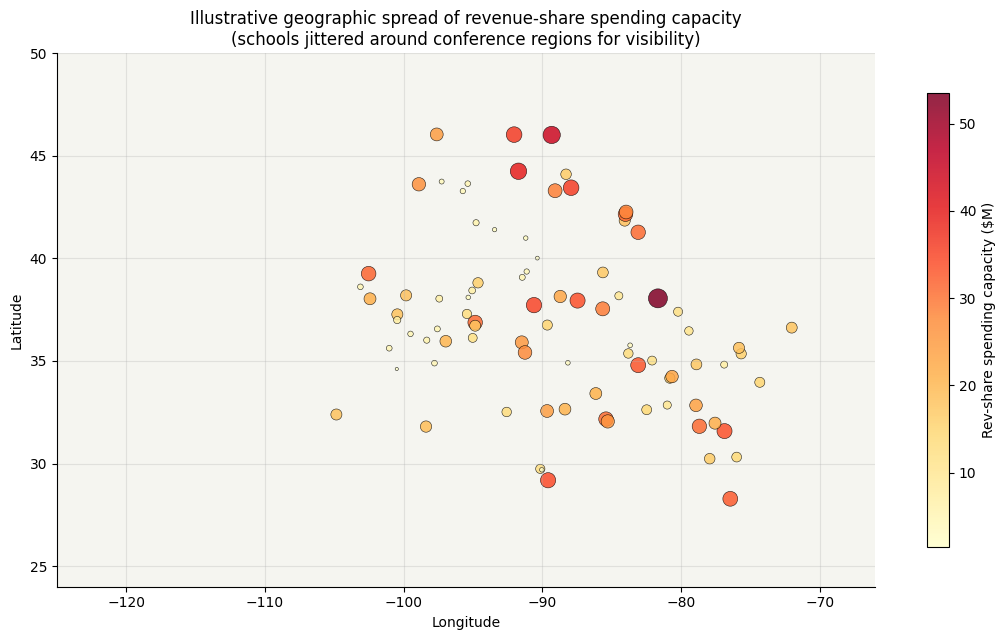

In [15]:
conf_hq = {"SEC": (33.0, -87.0), "Big Ten": (41.5, -88.0), "Big 12": (35.5, -97.5),
           "ACC": (35.5, -80.0), "Group of Five": (38.0, -95.0)}
jitter_lat = rng.normal(0, 3.5, n_schools)
jitter_lon = rng.normal(0, 5.5, n_schools)
schools["lat"] = [conf_hq[c][0] for c in schools["conference"]] + jitter_lat
schools["lon"] = [conf_hq[c][1] for c in schools["conference"]] + jitter_lon

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_xlim(-125, -66); ax.set_ylim(24, 50)
ax.set_facecolor("#f5f5f0"); ax.grid(alpha=0.3)

sc = ax.scatter(schools["lon"], schools["lat"], s=schools["spend_capacity_usd_million"] * 3.5,
                 c=schools["spend_capacity_usd_million"], cmap="YlOrRd", edgecolor="black", linewidth=0.4, alpha=0.85)
cbar = fig.colorbar(sc, ax=ax, shrink=0.85); cbar.set_label("Rev-share spending capacity ($M)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Illustrative geographic spread of revenue-share spending capacity\n(schools jittered around conference regions for visibility)")
plt.tight_layout()
plt.show()


## 8. One-Page Dashboard


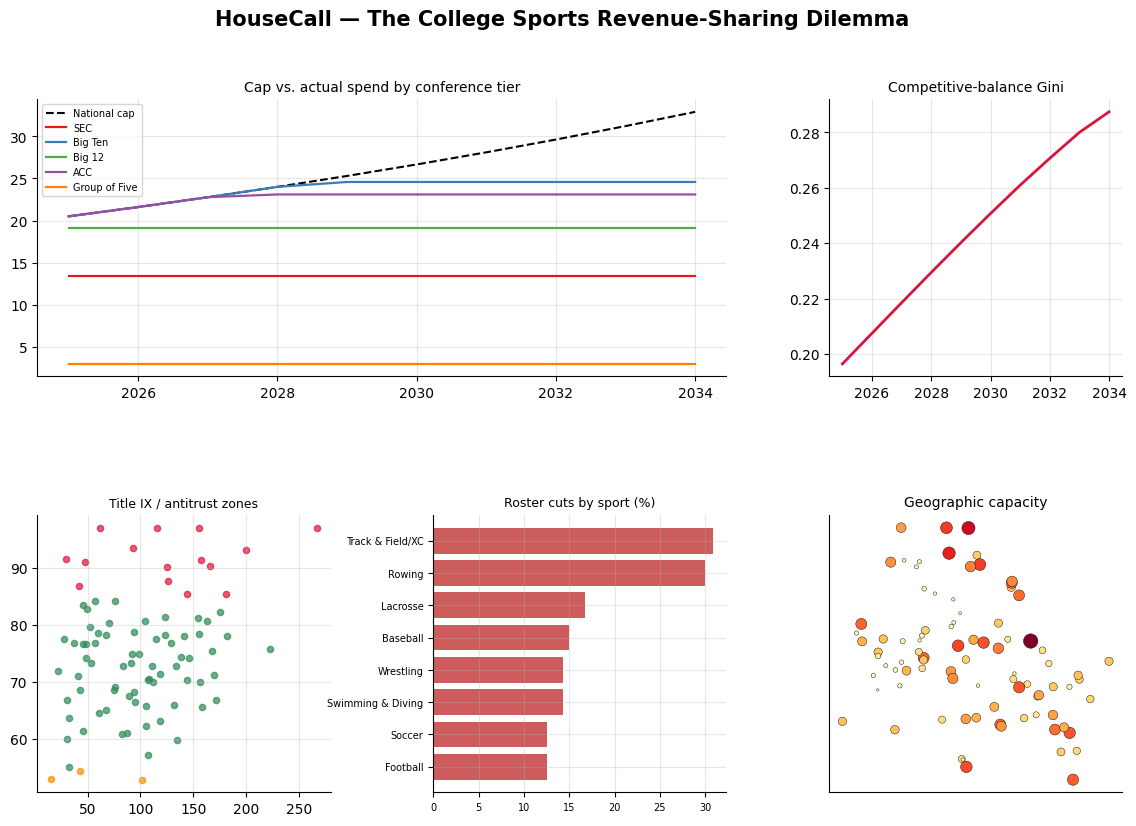

In [16]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(cap_years, cap_schedule, "k--", lw=1.5, label="National cap")
for conf, color in zip(conferences, sns.color_palette("Set1", len(conferences))):
    idx = schools.index[(schools["conference"] == conf) & opted_in][0]
    ax1.plot(cap_years, actual_spend_matrix[:, idx], color=color, lw=1.6, label=conf)
ax1.set_title("Cap vs. actual spend by conference tier", fontsize=10)
ax1.legend(fontsize=7)

ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(cap_years, gini_by_year, color="crimson", lw=2)
ax2.set_title("Competitive-balance Gini", fontsize=10)

ax3 = fig.add_subplot(gs[1, 0])
for zone, color in colors.items():
    subset = schools[schools["legal_risk_zone"] == zone]
    ax3.scatter(subset["annual_athletic_revenue_usd_million"], subset["pct_to_football_mbb"],
                color=color, s=20, alpha=0.7)
ax3.set_title("Title IX / antitrust zones", fontsize=9)

ax4 = fig.add_subplot(gs[1, 1])
order = roster_sports.sort_values("pct_cut", ascending=True)
ax4.barh(order["sport"], order["pct_cut"], color="indianred")
ax4.set_title("Roster cuts by sport (%)", fontsize=9)
ax4.tick_params(labelsize=7)

ax5 = fig.add_subplot(gs[1, 2])
sc = ax5.scatter(schools["lon"], schools["lat"], s=schools["spend_capacity_usd_million"]*2,
                   c=schools["spend_capacity_usd_million"], cmap="YlOrRd", edgecolor="black", linewidth=0.3)
ax5.set_xticks([]); ax5.set_yticks([]); ax5.set_title("Geographic capacity", fontsize=10)

fig.suptitle("HouseCall — The College Sports Revenue-Sharing Dilemma", fontsize=15, fontweight="bold")
plt.show()


## 9. Wrap-up: What This Data Does and Doesn't Settle

### What we built
Starting from the **real terms of the House v. NCAA settlement** —
validated by deriving the cap's implied growth rate from its two published
endpoints — we built:

- **NumPy**: a validated cap-growth projection, a full (years × schools)
  broadcast computing every school's actual spending capacity at once,
  boolean masks identifying capacity-constrained vs. always-at-cap schools,
  and a reused Gini-coefficient computation applied to athletic spending
  instead of household income
- **pandas**: conference-tier `groupby` summaries, `np.select`-based legal
  risk-zone classification, and sport-by-sport roster-cut comparison
- **Visualization**: the competitive-balance Gini trend (the core
  "widening gap" dilemma chart), the Title IX/antitrust trade-off scatter
  (the core "no safe split" dilemma chart), roster-cut bars, a geographic
  capacity map, and a one-page dashboard

### The dilemma, made concrete by the data
Section 4's rising Gini coefficient and Section 5's risk-zone scatter
**are** the dilemma: a single national cap mechanically favors the schools
that can already afford to reach it, and there is no revenue-split
percentage that a school can pick which is described in the cited legal
analysis as safe from *both* Title IX and antitrust exposure at once.

### Important caveats
- **School-level revenue, spending-capacity, split percentages, and roster
  data are synthetic** — real individual-school revenue-sharing budgets and
  splits are not yet public at this level of detail this early in
  implementation. Calibration follows well-documented aggregate patterns
  (P5 revenue concentration, football/MBB revenue dominance), not specific
  real institutions.
- The **settlement's dollar figures, dates, roster-limit example, and
  national-impact estimates are real**, cited to the sources listed below.
- The Title IX/antitrust "risk zones" in Section 5 are an **illustrative
  visualization of a real legal tension described in the cited source**,
  not a legal determination about any specific split percentage — actual
  Title IX compliance depends on much more than the revenue-share split alone.
- This notebook does not take a position on whether the settlement is good
  or bad for college sports; it presents the structural trade-offs the
  settlement created.

### Sources cited in this notebook
- CBS Sports, *"House v. NCAA settlement approved..."*, 2025
- Sports Shorts (Thompson Hine), *"Approved NCAA v. House Settlement Leaves Open Ended Legal Questions"*, Jul 2025 (updated Apr 2026)
- Crowell & Moring LLP, *"House Settlement Approved: How to Prepare for Implementation by July 1, 2025"*, Jul 2025
- Jackson Lewis, *"A New Era Begins..."*, Jun 2025
- Phelps, *"House v. NCAA Settlement Approved, Changing the Landscape of College Sports"*, Jun 2025
- Wingert Grebing Brubaker & Walshok LLP, *"The House v. NCAA Effect..."*, Feb 2026
- Honest Game, *"The House v. NCAA Settlement Explained..."*, Feb 2026
- Knight Commission, *Brief on House v. NCAA Settlement*, Feb 2025

### Where to go next
- Replace synthetic school revenue with real, publicly reported athletic
  department revenue (many public universities disclose this via NCAA
  financial reports or state open-records requests).
- Track actual school-by-school revenue-share allocations as they become
  public through CSC/CAPS reporting and journalism over the next few years.
- Extend the model to include NIL collective spending alongside direct
  revenue sharing, since both now coexist under the settlement.
- Revisit the competitive-balance Gini calculation with real spending data
  once several years of the settlement have played out.
